1)Implement a Deep Feed Forward ANN (Multi-Layer
Perceptron) using back propagation using a sequential
dataset. **bold text**

In [ ]:
import numpy as np
from sklearn import datasets
from sklearn.model_selection import train_test_split
from keras.models import Sequential
from keras.layers import Dense

# Load dataset
X, y = datasets.load_iris(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=42)

# Build model
model = Sequential([
    Dense(16, input_shape=(4,), activation='relu'),
    Dense(8, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(loss='mean_squared_error', optimizer='adam', metrics=['accuracy'])
model.summary()
model.fit(X_train, y_train, epochs=50, batch_size=8, verbose=1)

score = model.evaluate(X_test, y_test)
print("Loss:", score[0])
print("Accuracy:", score[1])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225 (900.00 B)

 Trainable params: 225 (900.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.2889 - loss: 0.9201    
Epoch 2/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.3444 - loss: 0.8084 
Epoch 3/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.3444 - loss: 0.7225     
Epoch 4/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.3444 - loss: 0.6642 
Epoch 5/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.3444 - loss: 0.6209 
Epoch 6/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.3444 - loss: 0.5958 
Epoch 7/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.3444 - loss: 0.5813 
Epoch 8/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.3444 - loss: 0.5712 
Epoch 9/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.3444 - loss: 0.5629 
Epoch 10/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.3444 - loss: 0.5551 
Epoch 11/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.3444 - loss: 0.5472 
Epoch 12/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - acc

2)Implement a Deep Feed Forward ANN (Multi-Layer
Perceptron) to classify images using MNIST datasets.

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Dense, Input
from sklearn.metrics import classification_report

# Load data
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()

# Normalize and flatten
X_train = X_train.reshape(60000, 784).astype("float32") / 255
X_test  = X_test.reshape(10000, 784).astype("float32") / 255

# Build model
model = Sequential([
    Input(shape=(784,)),
    Dense(128, activation='relu', kernel_initializer='he_normal'),
    Dense(64,  activation='relu', kernel_initializer='he_normal'),
    Dense(32,  activation='relu', kernel_initializer='he_normal'),
    Dense(10,  activation='softmax')
], name="DFF-Model")

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.summary()
model.fit(X_train, y_train, batch_size=64, epochs=5, verbose=1)

# Predict
pred_train = np.argmax(model.predict(X_train), axis=1)
pred_test  = np.argmax(model.predict(X_test),  axis=1)

print("\n--- Training Report ---")
print(classification_report(y_train, pred_train))
print("\n--- Test Report ---")
print(classification_report(y_test, pred_test))

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "DFF-Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 111,146 (434.16 KB)

 Trainable params: 111,146 (434.16 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - accuracy: 0.9168 - loss: 0.2808
Epoch 2/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.9660 - loss: 0.1125
Epoch 3/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9769 - loss: 0.0765
Epoch 4/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9811 - loss: 0.0602
Epoch 5/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9857 - loss: 0.0464
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

--- Training Report ---
              precision    recall  f1-score   support

           0       1.00      0.99      1.00      5923
           1       0.99      1.00      0.99      6742
           2       0.99      0.99      0.99      5958
           3       1.00      0.97      0.99      6131
           4       0.99      0.99      0.99      5842
           5       0.97      1.00      0.98      5421
           6       0.99      0.99      0.99      5918
           7       0.99      0.

3)Implement a CNN model with 2 layers of convolution. Use
padding and batch normalization.

Shape of X_train: (60000, 28, 28)
Shape of y_train: (60000,)
Shape of X_test: (10000, 28, 28)
Shape of y_test: (10000,)


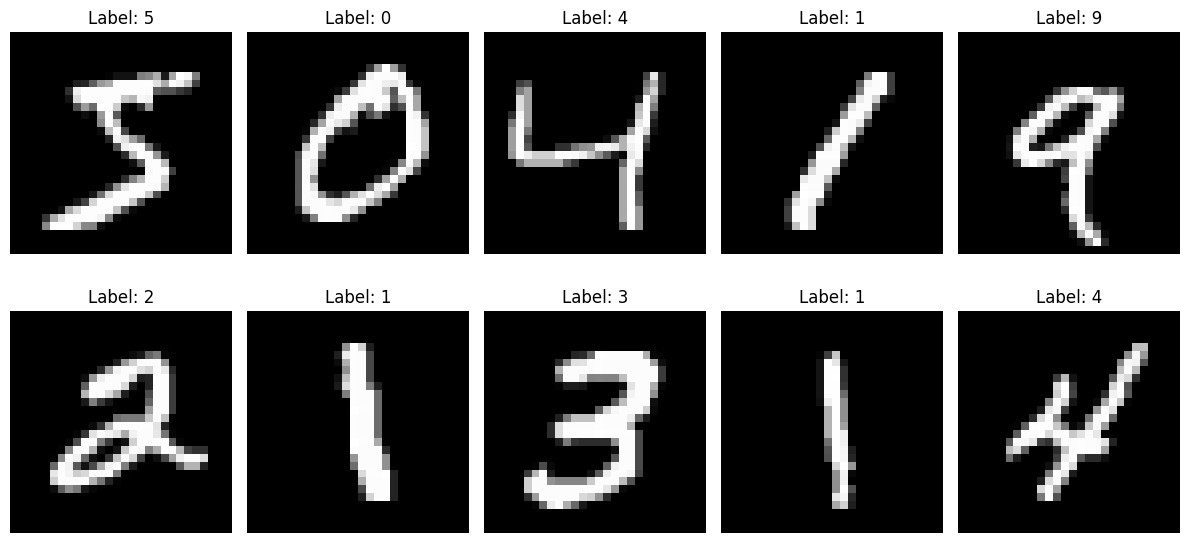

Image saved as mnist_samples.png
New shape of X_train: (60000, 784)
New shape of X_test: (10000, 784)


Model: "DFF-Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_7 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 111,146 (434.16 KB)

 Trainable params: 111,146 (434.16 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.9160 - loss: 0.2905
Epoch 2/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9662 - loss: 0.1151
Epoch 3/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9753 - loss: 0.0823
Epoch 4/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9801 - loss: 0.0628
Epoch 5/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9834 - loss: 0.0505
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

--- Evaluation on Training Data ---
              precision    recall  f1-score   support

           0       1.00      0.99      0.99      5923
           1       0.99      0.99      0.99      6742
           2       0.99      0.98      0.99      5958
           3       0.97      0.98      0.98      6131
           4       0.99      0.98      0.99      5842
           5       0.96      1.00      0.98      5421
           6       1.00      0.99      0.99      5918
           7       1.

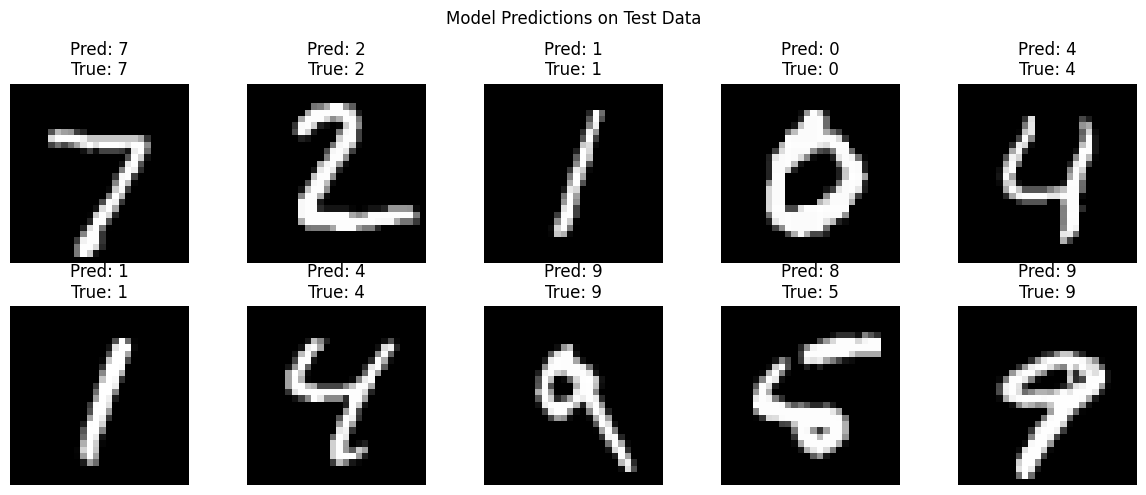

Prediction image saved as predictions.png


In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Dense, Input
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt

# Load data
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()

print("Shape of X_train:", X_train.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_test:", y_test.shape)

# ✅ Fixed image display
fig, axs = plt.subplots(2, 5, figsize=(12, 6), facecolor='white')
n = 0
for i in range(2):
    for j in range(5):
        axs[i, j].imshow(X_train[n], cmap='gray')   # ✅ added cmap='gray'
        axs[i, j].set_title(f"Label: {y_train[n]}")
        axs[i, j].axis('off')                        # ✅ cleaner look
        n += 1

plt.tight_layout()
plt.savefig('mnist_samples.png')   # ✅ saves image so you can see it
plt.show()
print("Image saved as mnist_samples.png")

# Normalize and flatten
X_train = X_train.reshape(60000, 784).astype("float32") / 255
X_test  = X_test.reshape(10000, 784).astype("float32") / 255

print("New shape of X_train:", X_train.shape)
print("New shape of X_test:",  X_test.shape)

# Build model
model = Sequential([
    Input(shape=(784,)),
    Dense(128, activation='relu', kernel_initializer='he_normal'),
    Dense(64,  activation='relu', kernel_initializer='he_normal'),
    Dense(32,  activation='relu', kernel_initializer='he_normal'),
    Dense(10,  activation='softmax')
], name="DFF-Model")

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()
model.fit(X_train, y_train, batch_size=64, epochs=5, verbose=1)

# Predictions
pred_train = np.argmax(model.predict(X_train), axis=1)
pred_test  = np.argmax(model.predict(X_test),  axis=1)

print("\n--- Evaluation on Training Data ---")
print(classification_report(y_train, pred_train))

print("\n--- Evaluation on Test Data ---")
print(classification_report(y_test, pred_test))

4).CNN Model with L2 (or L1) regularization and Dropout (combined)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 183s 213ms/step - accuracy: 0.7935 - loss: 0.7988 - val_accuracy: 0.8675 - val_loss: 0.5107
Epoch 2/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 210s 223ms/step - accuracy: 0.8592 - loss: 0.5639 - val_accuracy: 0.8812 - val_loss: 0.4685
Epoch 3/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 186s 204ms/step - accuracy: 0.8718 - loss: 0.5108 - val_accuracy: 0.8883 - val_loss: 0.4570
Epoch 4/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 208s 211ms/step - accuracy: 0.8787 - loss: 0.4846 - val_accuracy: 0.8828 - val_loss: 0.4511
Epoch 5/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 175s 207ms/step - accuracy: 0.8838 - loss: 0.4645 - val_accuracy: 0.8997 - val_loss: 0.4092
Epoch 6/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 169s 201ms/step - accuracy: 0.8871 - loss: 0.4500 - val_accuracy: 0.8948 - val_loss: 0.4100
Epoch 7/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 169s 200ms/step - accuracy: 0.8897 - loss: 0.4350 - val_accuracy: 0.8927 - val_loss: 0.4060
Epoch 8/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 171s 202ms/step - accuracy: 0.8951 -

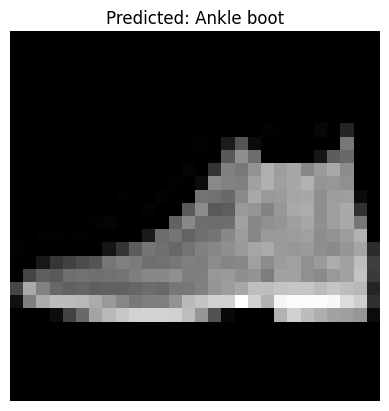

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from keras.datasets import fashion_mnist
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Activation, Dropout
from keras.utils import to_categorical
from keras import regularizers

# Load and preprocess the data
(train_X, train_Y), (test_X, test_Y) = fashion_mnist.load_data()
train_X = train_X.reshape(-1, 28, 28, 1).astype('float32') / 255.0
test_X = test_X.reshape(-1, 28, 28, 1).astype('float32') / 255.0

# One-hot encode the labels
train_Y_one_hot = to_categorical(train_Y, 10)
test_Y_one_hot = to_categorical(test_Y, 10)

# Set L2 regularization strength
l2_strength = 0.001

# Build the model
model = Sequential()

# 1st Conv Layer
model.add(Conv2D(32, (3, 3), padding='same', input_shape=(28, 28, 1),
                 kernel_regularizer=regularizers.l2(l2_strength)))
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

# 2nd Conv Layer
model.add(Conv2D(64, (3, 3), padding='same',
                 kernel_regularizer=regularizers.l2(l2_strength)))
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

# 3rd Conv Layer
model.add(Conv2D(128, (3, 3), padding='same',
                 kernel_regularizer=regularizers.l2(l2_strength)))
model.add(Activation('relu'))

# 4th Conv Layer
model.add(Conv2D(128, (3, 3), padding='same',
                 kernel_regularizer=regularizers.l2(l2_strength)))
model.add(Activation('relu'))

# Flatten + Dense
model.add(Flatten())
model.add(Dense(128, activation='relu',
                kernel_regularizer=regularizers.l2(l2_strength)))
model.add(Dropout(0.5))  # Dropout after dense layer
model.add(Dense(10, activation='softmax'))

# Compile model
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Train model
model.fit(train_X, train_Y_one_hot, epochs=10, batch_size=64, validation_split=0.1)

# Evaluate
test_loss, test_acc = model.evaluate(test_X, test_Y_one_hot)
print("Test Loss:", test_loss)
print("Test Accuracy:", test_acc)

# Predict and visualize
predictions = model.predict(test_X)
labels = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
          'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
predicted_class = np.argmax(predictions[0])
print(f"Predicted label: {predicted_class} ({labels[predicted_class]})")

plt.imshow(test_X[0].reshape(28, 28), cmap='gray')
plt.title(f"Predicted: {labels[predicted_class]}")
plt.axis('off')
plt.show()


5)Implement a python program to demonstrate the Image
captioning.

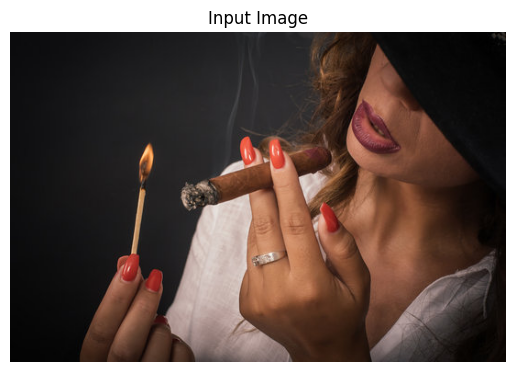

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/287 [00:00<?, ?B/s]

The image processor of type `BlipImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/506 [00:00<?, ?B/s]

...

pytorch_model.bin:   0%|          | 0.00/990M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie text_decoder.cls.predictions.bias to text_decoder.cls.predictions.decoder.bias, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie text_decoder.bert.embeddings.word_embeddings.weight to text_decoder.cls.predictions.decoder.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
BlipForConditionalGeneration LOAD REPORT from: Salesforce/blip-image-captioning-base
Key                                       | Status     |  | 
------------------------------------------+------------+--+-
text_decoder.bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identic

model.safetensors:   0%|          | 0.00/990M [00:00<?, ?B/s]

Generated Caption:
a woman in a white shirt holding a cigarette


In [10]:
import torch
from transformers import BlipProcessor, BlipForConditionalGeneration
from PIL import Image
import requests
import matplotlib.pyplot as plt

# Load a sample image (replace with your own URL or local path)
image_url = "https://t4.ftcdn.net/jpg/01/67/29/67/360_F_167296790_tR1y8W6Gm7O7hKYPdByHVWwSRgKCzIFi.jpg"
image = Image.open(requests.get(image_url, stream=True).raw).convert("RGB")

# Display the image
plt.imshow(image)
plt.axis('off')
plt.title("Input Image")
plt.show()

# Load BLIP processor and model
processor = BlipProcessor.from_pretrained("Salesforce/blip-image-captioning-base")
model = BlipForConditionalGeneration.from_pretrained("Salesforce/blip-image-captioning-base")

# Preprocess the image
inputs = processor(images=image, return_tensors="pt")

# Generate caption
with torch.no_grad():
    caption_ids = model.generate(**inputs)
    caption = processor.decode(caption_ids[0], skip_special_tokens=True)

print("Generated Caption:")
print(caption)


6)Implement a text classification model using Bidirectional
LSTM on a suitable dataset.

In [1]:
import numpy as np
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam

np.random.seed(42)

vocab_size = 10000
max_len    = 200   # reduced from 500 for faster training

(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=vocab_size)
x_train = pad_sequences(x_train, maxlen=max_len)
x_test  = pad_sequences(x_test,  maxlen=max_len)

model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=64),
    Bidirectional(LSTM(64, return_sequences=False)),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer=Adam(), loss='binary_crossentropy', metrics=['accuracy'])
model.summary()
model.fit(x_train, y_train, epochs=3, batch_size=64, validation_data=(x_test, y_test))

loss, acc = model.evaluate(x_test, y_test)
print(f"Test Accuracy: {acc*100:.2f}%")

# Sample prediction
pred = model.predict(np.array([x_test[100]]))
print("Prediction:", "Positive" if pred[0][0] > 0.5 else "Negative")

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/3
391/391 ━━━━━━━━━━━━━━━━━━━━ 244s 614ms/step - accuracy: 0.7713 - loss: 0.4569 - val_accuracy: 0.8651 - val_loss: 0.3286
Epoch 2/3
391/391 ━━━━━━━━━━━━━━━━━━━━ 173s 387ms/step - accuracy: 0.8957 - loss: 0.2709 - val_accuracy: 0.8694 - val_loss: 0.3111
Epoch 3/3
391/391 ━━━━━━━━━━━━━━━━━━━━ 160s 409ms/step - accuracy: 0.9243 - loss: 0.2043 - val_accuracy: 0.8682 - val_loss: 0.3087
782/782 ━━━━━━━━━━━━━━━━━━━━ 38s 49ms/step - accuracy: 0.8682 - loss: 0.3087
Test Accuracy: 86.82%
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 333ms/step
Prediction: Negative


7)Implement Auto encoders for image denoising on MNIST
dataset.

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 8)      │         1,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 8)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 8)        │           584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 14, 14, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 16)     │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 28, 28, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 1)      │           145 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,217 (12.57 KB)

 Trainable params: 3,217 (12.57 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 96s 201ms/step - loss: 0.1973 - val_loss: 0.1189
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 128s 171ms/step - loss: 0.1134 - val_loss: 0.1074
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 84s 176ms/step - loss: 0.1065 - val_loss: 0.1033
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 80s 170ms/step - loss: 0.1030 - val_loss: 0.1006
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 83s 172ms/step - loss: 0.1009 - val_loss: 0.0989
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step


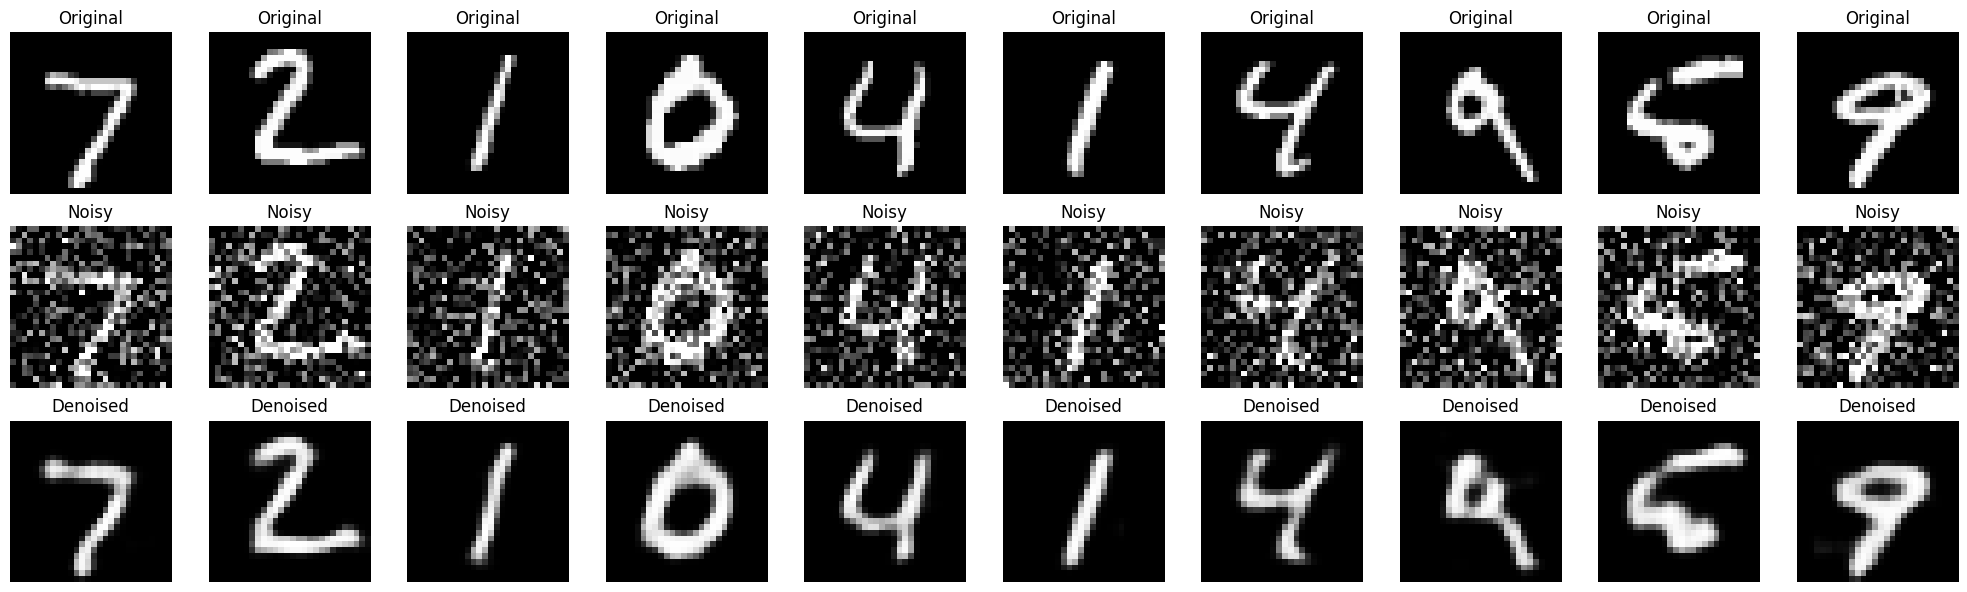

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models

# Load and prepare data
(x_train, _), (x_test, _) = tf.keras.datasets.mnist.load_data()
x_train = x_train.astype('float32') / 255.0
x_test  = x_test.astype('float32')  / 255.0
x_train = x_train.reshape(-1, 28, 28, 1)
x_test  = x_test.reshape(-1,  28, 28, 1)

# Add noise
noise_factor = 0.4
x_train_noisy = np.clip(x_train + noise_factor * np.random.randn(*x_train.shape), 0, 1)
x_test_noisy  = np.clip(x_test  + noise_factor * np.random.randn(*x_test.shape),  0, 1)

# Build autoencoder
inp = layers.Input(shape=(28, 28, 1))

# Encoder
x = layers.Conv2D(16, (3,3), activation='relu', padding='same')(inp)
x = layers.MaxPooling2D((2,2), padding='same')(x)
x = layers.Conv2D(8,  (3,3), activation='relu', padding='same')(x)
encoded = layers.MaxPooling2D((2,2), padding='same')(x)

# Decoder
x = layers.Conv2D(8,  (3,3), activation='relu', padding='same')(encoded)
x = layers.UpSampling2D((2,2))(x)
x = layers.Conv2D(16, (3,3), activation='relu', padding='same')(x)
x = layers.UpSampling2D((2,2))(x)
decoded = layers.Conv2D(1, (3,3), activation='sigmoid', padding='same')(x)

autoencoder = models.Model(inp, decoded)
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')
autoencoder.summary()

autoencoder.fit(x_train_noisy, x_train,
                epochs=5, batch_size=128, shuffle=True,
                validation_data=(x_test_noisy, x_test))

# Visualize results
decoded_imgs = autoencoder.predict(x_test_noisy)

n = 10
plt.figure(figsize=(20, 6))
for i in range(n):
    plt.subplot(3, n, i+1)
    plt.imshow(x_test[i].reshape(28,28), cmap='gray')
    plt.title("Original"); plt.axis('off')

    plt.subplot(3, n, i+1+n)
    plt.imshow(x_test_noisy[i].reshape(28,28), cmap='gray')
    plt.title("Noisy"); plt.axis('off')

    plt.subplot(3, n, i+1+2*n)
    plt.imshow(decoded_imgs[i].reshape(28,28), cmap='gray')
    plt.title("Denoised"); plt.axis('off')

plt.tight_layout()
plt.show()

8)Implement a Generative Adversarial Network using MNIST
dataset to train a model that generates realistic handwritten
digits.

100%|██████████| 9.91M/9.91M [00:01<00:00, 5.26MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 154kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.47MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.70MB/s]


Epoch [1/10]  d_loss: 0.3466  g_loss: 2.7687
Epoch [2/10]  d_loss: 0.6934  g_loss: 1.9719
Epoch [3/10]  d_loss: 0.6421  g_loss: 2.6711
Epoch [4/10]  d_loss: 0.4764  g_loss: 2.4291
Epoch [5/10]  d_loss: 2.0201  g_loss: 1.0455
Epoch [6/10]  d_loss: 1.0479  g_loss: 1.3555
Epoch [7/10]  d_loss: 0.7565  g_loss: 1.7939
Epoch [8/10]  d_loss: 1.4749  g_loss: 1.7501
Epoch [9/10]  d_loss: 0.3087  g_loss: 3.2043
Epoch [10/10]  d_loss: 0.6694  g_loss: 2.9375


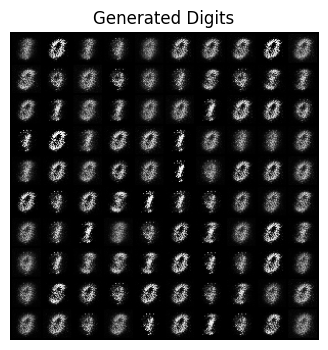

Training complete.


In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import torchvision

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

latent_size   = 64
hidden_size   = 256
image_size    = 784
batch_size    = 100
num_epochs    = 10
learning_rate = 0.0002

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])
mnist       = datasets.MNIST(root='./data', train=True, transform=transform, download=True)
data_loader = DataLoader(mnist, batch_size=batch_size, shuffle=True)

class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(latent_size, hidden_size), nn.LeakyReLU(0.2),
            nn.Linear(hidden_size, hidden_size), nn.LeakyReLU(0.2),
            nn.Linear(hidden_size, image_size),  nn.Tanh()
        )
    def forward(self, z): return self.model(z)

class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(image_size, hidden_size), nn.LeakyReLU(0.2),
            nn.Linear(hidden_size, hidden_size), nn.LeakyReLU(0.2),
            nn.Linear(hidden_size, 1), nn.Sigmoid()
        )
    def forward(self, x): return self.model(x)

G = Generator().to(device)
D = Discriminator().to(device)
criterion    = nn.BCELoss()
d_optimizer  = optim.Adam(D.parameters(), lr=learning_rate)
g_optimizer  = optim.Adam(G.parameters(), lr=learning_rate)

def show_images(fake_images):
    fake_images = fake_images.reshape(-1, 1, 28, 28)
    grid = torchvision.utils.make_grid(fake_images, nrow=10, normalize=True)
    plt.figure(figsize=(10, 4))
    plt.imshow(np.transpose(grid.cpu().numpy(), (1, 2, 0)))
    plt.axis('off')
    plt.title("Generated Digits")
    plt.show()

for epoch in range(num_epochs):
    for images, _ in data_loader:
        bs = images.size(0)
        images = images.reshape(bs, -1).to(device)

        real_labels = torch.ones(bs, 1).to(device)
        fake_labels = torch.zeros(bs, 1).to(device)

        # Train Discriminator
        d_loss = criterion(D(images), real_labels)
        z = torch.randn(bs, latent_size).to(device)
        d_loss += criterion(D(G(z).detach()), fake_labels)
        D.zero_grad(); d_loss.backward(); d_optimizer.step()

        # Train Generator
        z = torch.randn(bs, latent_size).to(device)
        g_loss = criterion(D(G(z)), real_labels)
        G.zero_grad(); g_loss.backward(); g_optimizer.step()

    print(f"Epoch [{epoch+1}/{num_epochs}]  d_loss: {d_loss:.4f}  g_loss: {g_loss:.4f}")

# Show final generated images
with torch.no_grad():
    z = torch.randn(100, latent_size).to(device)
    show_images(G(z))

print("Training complete.")

9)Implement a Python program to build a model for face
recognition using Python and Open-CV.

In [4]:
import cv2
import matplotlib.pyplot as plt
import urllib.request
import numpy as np

# Download a sample image with faces
url = "https://upload.wikimedia.org/wikipedia/commons/thumb/e/ec/Mona_Lisa%2C_by_Leonardo_da_Vinci%2C_from_C2RMF_retouched.jpg/300px-Mona_Lisa%2C_by_Leonardo_da_Vinci%2C_from_C2RMF_retouched.jpg"
urllib.request.urlretrieve(url, "test_face.jpg")

# Load image
frame = cv2.imread("test_face.jpg")
gray  = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

# Load Haar cascade
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')

# Detect faces
faces = face_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=3)
print(f"Faces detected: {len(faces)}")

for (x, y, w, h) in faces:
    cv2.rectangle(frame, (x, y), (x+w, y+h), (0, 255, 0), 2)

# Display with matplotlib (works in Jupyter)
plt.figure(figsize=(8, 8))
plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
plt.title(f"Detected {len(faces)} face(s)")
plt.axis('off')
plt.show()

HTTPError: HTTP Error 403: Forbidden

10)Implement an RNN for sentiment analysis using IMDB
movie dataset.

In [5]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense

vocab_size     = 10000
maxlen         = 200   # reduced for speed
embedding_dim  = 32

(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=vocab_size)
x_train = pad_sequences(x_train, maxlen=maxlen)
x_test  = pad_sequences(x_test,  maxlen=maxlen)

model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim),
    SimpleRNN(64),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()
model.fit(x_train, y_train, epochs=3, batch_size=64, validation_split=0.2)

loss, acc = model.evaluate(x_test, y_test)
print(f"Test Accuracy: {acc*100:.2f}%")

# Custom prediction
word_index = imdb.get_word_index()
word_index = {k: (v+3) for k,v in word_index.items()}
word_index.update({"<PAD>":0, "<START>":1, "<UNK>":2, "<UNUSED>":3})

def predict_sentiment(text):
    tokens  = [1] + [word_index.get(w.lower(), 2) for w in text.split()]
    padded  = pad_sequences([tokens], maxlen=maxlen)
    score   = model.predict(padded)[0][0]
    label   = "Positive 😀" if score > 0.5 else "Negative 😞"
    print(f"Review: {text}")
    print(f"Sentiment: {label}  (score: {score:.4f})")

predict_sentiment("This movie was fantastic! The story was compelling and the acting was great.")
predict_sentiment("Terrible film. Waste of time, boring and poorly made.")

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 23s 66ms/step - accuracy: 0.6331 - loss: 0.6135 - val_accuracy: 0.8052 - val_loss: 0.4372
Epoch 2/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 22s 69ms/step - accuracy: 0.8501 - loss: 0.3548 - val_accuracy: 0.8134 - val_loss: 0.4184
Epoch 3/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 22s 70ms/step - accuracy: 0.8863 - loss: 0.2835 - val_accuracy: 0.8344 - val_loss: 0.3957
782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.8401 - loss: 0.3877
Test Accuracy: 84.01%
1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 1s 1us/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 250ms/step
Review: This movie was fantastic! The story was compelling and the acting was great.
Sentiment: Positive 😀  (score: 0.9220)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
Review: Terrible film. Waste of time, boring and poorly made.
Sentiment: Negative 😞  (score: 0.0097)
